# Source: notebook4a62b06a66.ipynb

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# Load dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if file == 'train.csv':
            path = os.path.join(dirname, file)

df = pd.read_csv(path)

# Clean target column
df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['Time_taken(min)'] = pd.to_numeric(
    df['Time_taken(min)'],
    errors='coerce'
)

# Remove missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop('Time_taken(min)', axis=1)
y = df['Time_taken(min)']

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

                    Feature  Importance
3   Delivery_person_Ratings    0.206889
12     Road_traffic_density    0.129114
11        Weatherconditions    0.117072
13        Vehicle_condition    0.089928
2       Delivery_person_Age    0.086292
9               Time_Orderd    0.066230
16      multiple_deliveries    0.048500
10        Time_Order_picked    0.040328
8                Order_Date    0.033976
0                        ID    0.030924


# Source: notebook27b434fff0.ipynb

Dataset Loaded: /kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv

Columns:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Using Column: Time_Orderd


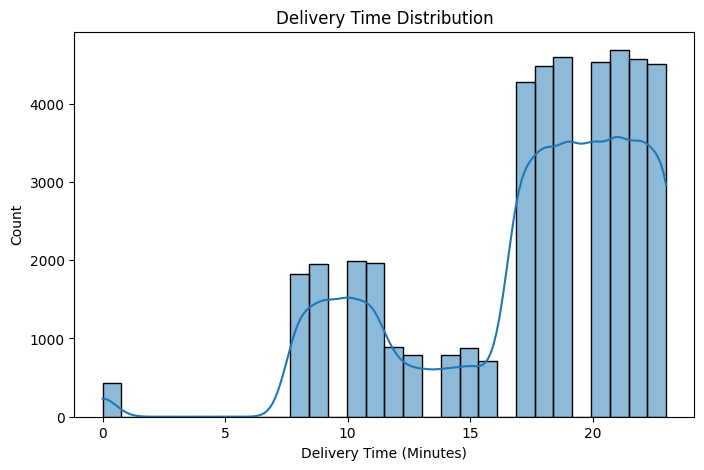

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# LOAD DATASET
# ==========================

csv_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if file.endswith('.csv') and 'train' in file.lower():
            csv_file = os.path.join(dirname, file)
            break

if csv_file is None:
    print("Train.csv not found")
else:
    print("Dataset Loaded:", csv_file)

df = pd.read_csv(csv_file)

# ==========================
# CHECK COLUMNS
# ==========================

print("\nColumns:")
print(df.columns.tolist())

# ==========================
# FIND DELIVERY TIME COLUMN
# ==========================

time_col = None

for col in df.columns:
    if "time" in col.lower():
        time_col = col
        break

print("\nUsing Column:", time_col)

# ==========================
# CLEAN DELIVERY TIME COLUMN
# ==========================

df[time_col] = (
    df[time_col]
    .astype(str)
    .str.extract(r'(\d+)')
)

df[time_col] = pd.to_numeric(df[time_col])

# ==========================
# PLOT GRAPH
# ==========================

plt.figure(figsize=(8,5))

sns.histplot(
    df[time_col],
    bins=30,
    kde=True
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Count")

plt.show()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Source: notebook01fc87eb62.ipynb

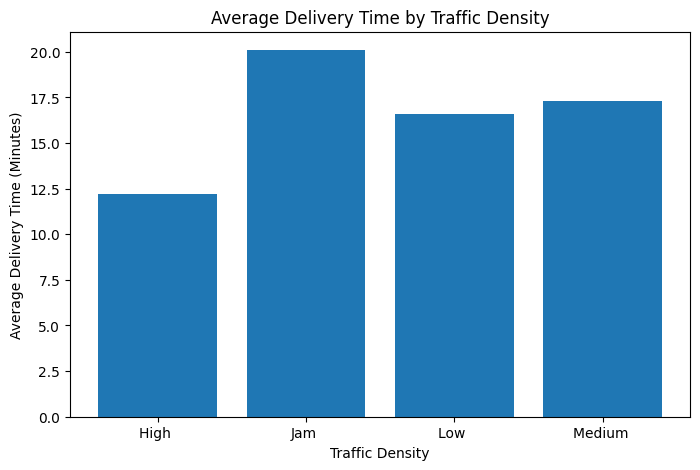

In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset first if df doesn't exist
# df = pd.read_csv("your_file.csv")

# Find the time column automatically
time_col = [col for col in df.columns if 'time' in col.lower()][0]

# Clean time column
df[time_col] = (
    df[time_col]
    .astype(str)
    .str.extract(r'(\d+)')
)

df[time_col] = pd.to_numeric(df[time_col])

# Average delivery time for each traffic level
traffic_delay = df.groupby('Road_traffic_density')[time_col].mean().reset_index()

# Simple bar graph
plt.figure(figsize=(8,5))

plt.bar(
    traffic_delay['Road_traffic_density'],
    traffic_delay[time_col]
)

plt.title('Average Delivery Time by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Average Delivery Time (Minutes)')

plt.show()




    

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Source: notebook9173aff390.ipynb

Dataset: /kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv
Weather Column: Weatherconditions
Time Column: Time_Orderd

Average Delivery Time:
Weatherconditions
conditions Sandstorms    17.478655
conditions Cloudy        17.469274
conditions Windy         17.441594
conditions Fog           17.409042
conditions Stormy        17.393812
conditions Sunny         17.350260
Name: Time_Orderd, dtype: float64


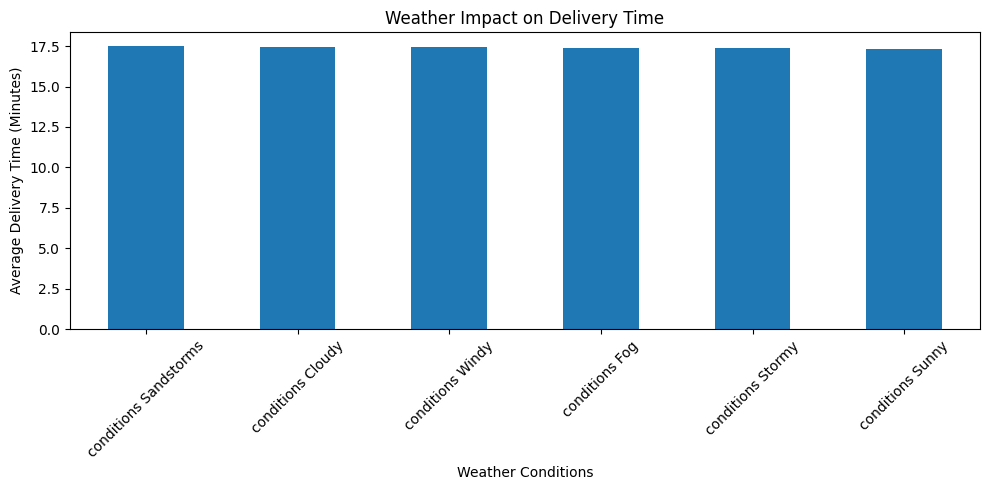

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import pandas as pd
import os
import matplotlib.pyplot as plt

# =====================================
# LOAD TRAIN DATASET
# =====================================

train_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if 'train' in file.lower() and file.endswith('.csv'):
            train_file = os.path.join(dirname, file)
            break

print("Dataset:", train_file)

df = pd.read_csv(train_file)

# =====================================
# FIND WEATHER COLUMN
# =====================================

weather_col = None

for col in df.columns:
    if 'weather' in col.lower():
        weather_col = col
        break

# =====================================
# FIND TIME COLUMN
# =====================================

time_col = None

for col in df.columns:
    if 'time' in col.lower():
        time_col = col
        break

print("Weather Column:", weather_col)
print("Time Column:", time_col)

# =====================================
# CLEAN TIME COLUMN
# =====================================

df[time_col] = (
    df[time_col]
    .astype(str)
    .str.extract(r'(\d+)')
)

df[time_col] = pd.to_numeric(df[time_col])

# =====================================
# REMOVE MISSING VALUES
# =====================================

df = df.dropna(subset=[weather_col, time_col])

# =====================================
# CALCULATE AVERAGE DELIVERY TIME
# =====================================

weather_avg = (
    df.groupby(weather_col)[time_col]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Delivery Time:")
print(weather_avg)

# =====================================
# BAR GRAPH
# =====================================

plt.figure(figsize=(10,5))

weather_avg.plot(kind='bar')

plt.title('Weather Impact on Delivery Time')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



       

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Source: notebook2cf4173e83.ipynb

Dataset Loaded: /kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']
   Vehicle_condition  Time_Orderd
0                  0    17.410190
1                  1    17.420469
2                  2    17.441197
3                  3          NaN


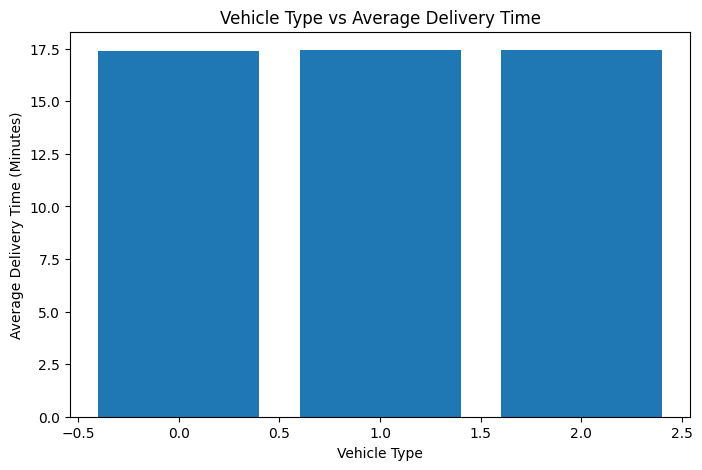

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import pandas as pd
import os
import matplotlib.pyplot as plt

# =========================
# LOAD DATASET
# =========================

csv_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if file.endswith('.csv') and 'sample' not in file.lower():
            csv_file = os.path.join(dirname, file)
            break

print("Dataset Loaded:", csv_file)

df = pd.read_csv(csv_file)

# =========================
# CHECK COLUMNS
# =========================

print(df.columns.tolist())

# =========================
# FIND VEHICLE COLUMN
# =========================

vehicle_col = [col for col in df.columns if 'vehicle' in col.lower()][0]

# =========================
# FIND TIME COLUMN
# =========================

time_col = [col for col in df.columns if 'time' in col.lower()][0]

# =========================
# CLEAN TIME COLUMN
# =========================

df[time_col] = (
    df[time_col]
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df[time_col] = pd.to_numeric(df[time_col])

# =========================
# AVERAGE DELIVERY TIME
# =========================

vehicle_avg = (
    df.groupby(vehicle_col)[time_col]
    .mean()
    .reset_index()
)

print(vehicle_avg)

# =========================
# GRAPH
# =========================

plt.figure(figsize=(8,5))

plt.bar(
    vehicle_avg[vehicle_col],
    vehicle_avg[time_col]
)

plt.title('Vehicle Type vs Average Delivery Time')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Delivery Time (Minutes)')

plt.show()


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

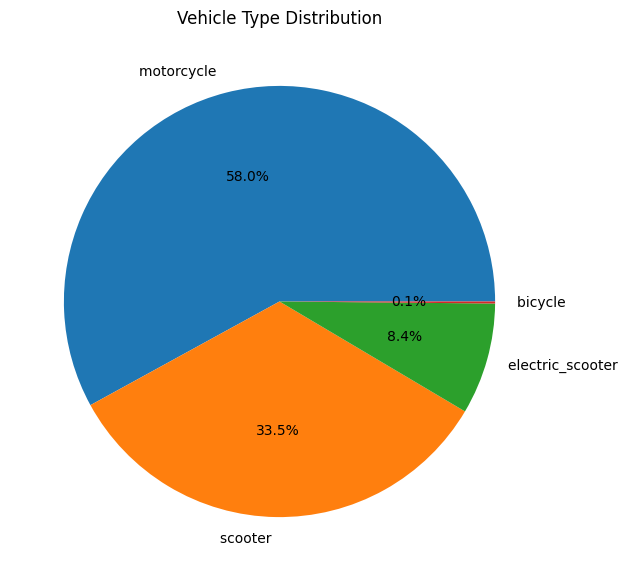

In [2]:
import matplotlib.pyplot as plt

vehicle_count = df['Type_of_vehicle'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    vehicle_count,
    labels=vehicle_count.index,
    autopct='%1.1f%%'
)

plt.title('Vehicle Type Distribution')

plt.show()

In [3]:
# Average Delivery Time by Vehicle Type

df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'])

vehicle_table = (
    df.groupby('Type_of_vehicle')['Time_taken(min)']
    .mean()
    .reset_index()
)

vehicle_table.columns = [
    'Vehicle Type',
    'Average Delivery Time'
]

vehicle_table

,Vehicle Type,Average Delivery Time
0,bicycle,26.426471
1,electric_scooter,24.470110
2,motorcycle,27.605674
3,scooter,24.480754


# Source: notebook16c9402328.ipynb

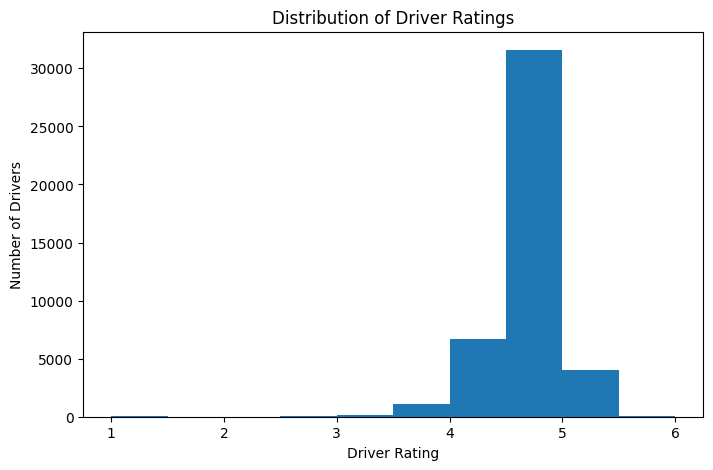

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import matplotlib.pyplot as plt

# Convert ratings to numeric
df['Delivery_person_Ratings'] = pd.to_numeric(
    df['Delivery_person_Ratings'],
    errors='coerce'
)

plt.figure(figsize=(8,5))

plt.hist(
    df['Delivery_person_Ratings'].dropna(),
    bins=10
)

plt.title('Distribution of Driver Ratings')
plt.xlabel('Driver Rating')
plt.ylabel('Number of Drivers')

plt.show()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
driver_table = (
    df.groupby('Delivery_person_Ratings')['Time_taken(min)']
    .mean()
    .reset_index()
)

driver_table.columns = [
    'Driver Rating',
    'Average Delivery Time'
]

driver_table

,Driver Rating,Average Delivery Time
0,1.0,26.000000
1,2.5,37.300000
2,2.6,38.590909
3,2.7,35.863636
4,2.8,36.631579
5,2.9,38.526316
6,3.0,32.666667
7,3.1,36.551724
8,3.2,36.344828
9,3.3,36.040000


# Source: notebook5f1f7b6f5f.ipynb

  Festival  Time_taken(min)
0     NaN         11.166667
1      No         25.984843
2     Yes         45.517857


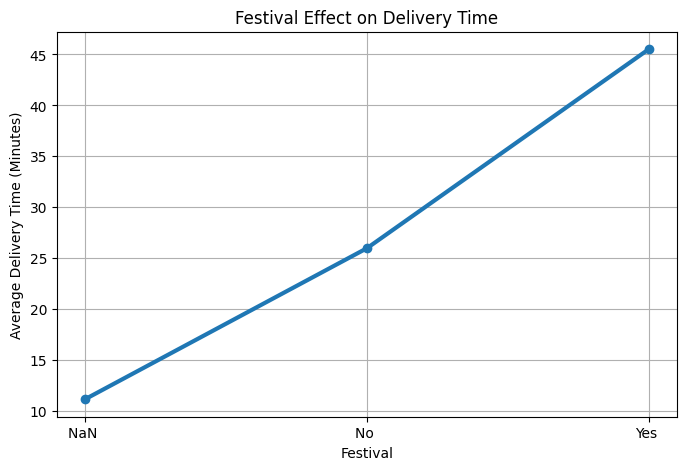

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import os
import matplotlib.pyplot as plt

# Load dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if file == 'train.csv':
            path = os.path.join(dirname, file)

df = pd.read_csv(path)

# Convert time column to numeric
df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['Time_taken(min)'] = pd.to_numeric(
    df['Time_taken(min)'],
    errors='coerce'
)

# Festival effect
festival_avg = (
    df.groupby('Festival')['Time_taken(min)']
    .mean()
    .reset_index()
)

print(festival_avg)

# Line graph
plt.figure(figsize=(8,5))

plt.plot(
    festival_avg['Festival'],
    festival_avg['Time_taken(min)'],
    marker='o',
    linewidth=3
)

plt.title('Festival Effect on Delivery Time')
plt.xlabel('Festival')
plt.ylabel('Average Delivery Time (Minutes)')
plt.grid(True)

plt.show()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Source: notebook4cbd1a67ad.ipynb

Using Dataset:
/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv

Dataset Shape:
(45593, 20)

Columns:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Accuracy:
0.9736813247066565

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8819
           1       0.70      0.35      0.46       300

    accuracy                           0.97      9119
   macro avg       0.84      0.67      0.73      9119
weighted avg       0.97      0.97      0.97      9119


Top Delay Factors:
                    Feature  Importance
2                Order_Date    0.122

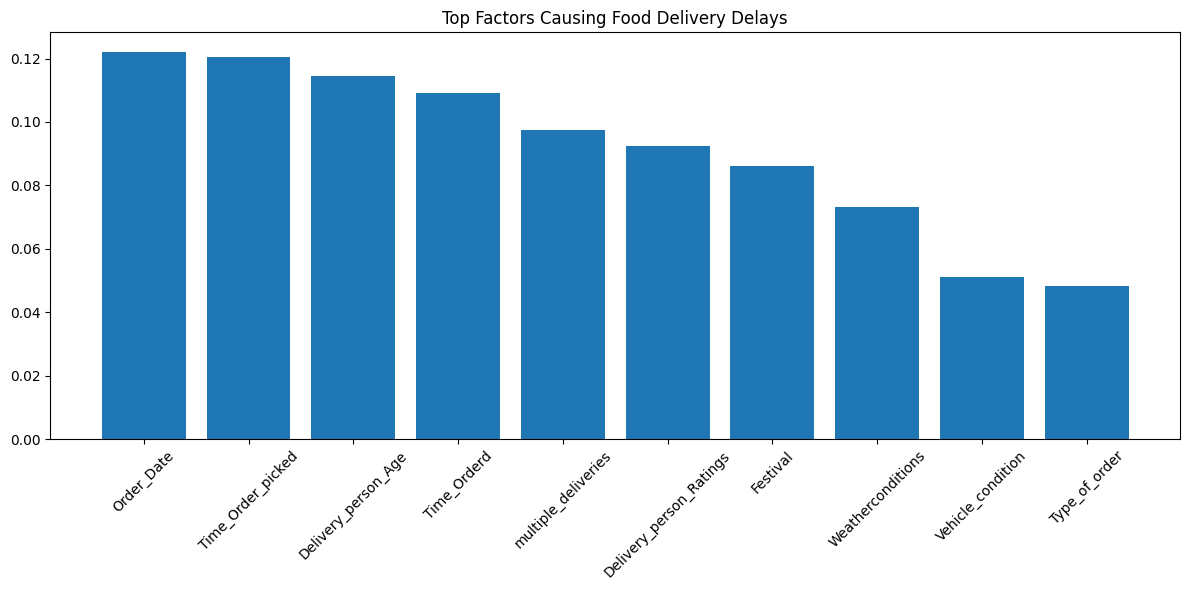


Root_Cause_Analysis.csv saved successfully


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# ==========================================
# FOOD DELIVERY DELAY PREDICTION
# ROOT CAUSE ANALYSIS
# ==========================================
# =====================================================
# FOOD DELIVERY DELAY PREDICTION & ROOT CAUSE ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# =====================================================
# FIND TRAIN FILE AUTOMATICALLY
# =====================================================

train_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if 'train' in file.lower() and file.endswith('.csv'):
            train_path = os.path.join(dirname, file)
            break

if train_path is None:
    raise Exception("Train.csv not found. Check dataset files.")

print("Using Dataset:")
print(train_path)

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv(train_path)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

# =====================================================
# CLEAN DATA
# =====================================================

df.columns = df.columns.str.strip()

# Clean delivery time column
target_col = 'Time_taken(min)'

if target_col not in df.columns:
    target_col = 'Time_taken (min)'

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.extract(r'(\d+)')
)

df[target_col] = pd.to_numeric(df[target_col])

# Create Delay Target

df['Delayed'] = np.where(df[target_col] > 45, 1, 0)

# Replace NaN string values
df.replace('NaN', np.nan, inplace=True)

# Fill missing values
for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df[col] = df[col].fillna(df[col].median())

# =====================================================
# REMOVE UNUSED COLUMNS
# =====================================================

drop_cols = [
    'ID',
    'Delivery_person_ID',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    target_col
]

existing_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=existing_cols)

# =====================================================
# LABEL ENCODING
# =====================================================

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

# =====================================================
# FEATURES & TARGET
# =====================================================

X = df.drop('Delayed', axis=1)
y = df['Delayed']

# =====================================================
# SPLIT DATA
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =====================================================
# RANDOM FOREST MODEL
# =====================================================

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =====================================================
# ROOT CAUSE ANALYSIS
# =====================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Delay Factors:")
print(importance.head(15))

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(12,6))

plt.bar(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xticks(rotation=45)
plt.title("Top Factors Causing Food Delivery Delays")
plt.tight_layout()
plt.show()

# =====================================================
# SAVE RESULTS
# =====================================================

importance.to_csv(
    "Root_Cause_Analysis.csv",
    index=False
)

print("\nRoot_Cause_Analysis.csv saved successfully")



    


   


    








   


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Source: notebookc44cd91418.ipynb

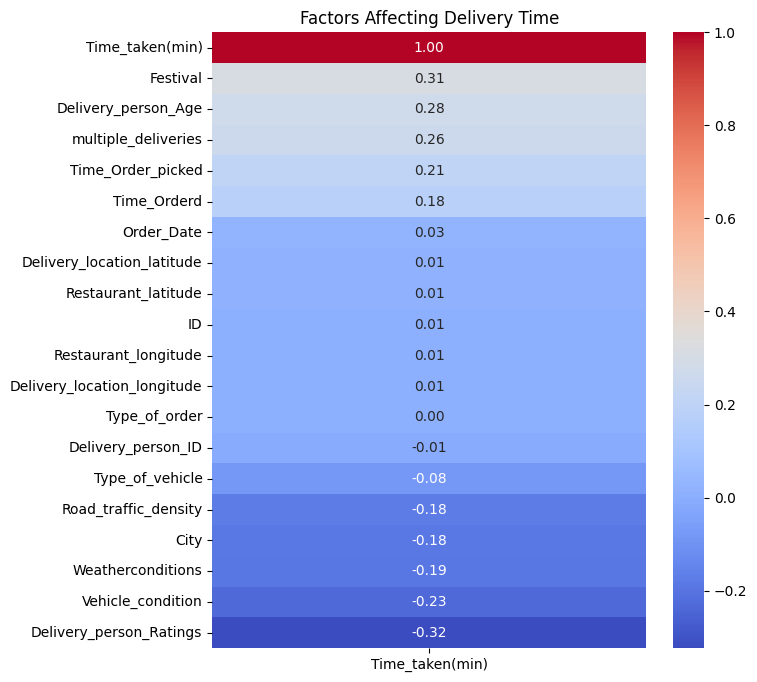

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# =====================
# LOAD DATASET
# =====================

for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        if file == 'train.csv':
            path = os.path.join(dirname, file)

df = pd.read_csv(path)

# =====================
# CLEAN TIME COLUMN
# =====================

df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['Time_taken(min)'] = pd.to_numeric(
    df['Time_taken(min)'],
    errors='coerce'
)

# =====================
# ENCODE CATEGORICAL COLUMNS
# =====================

heat_df = df.copy()

le = LabelEncoder()

for col in heat_df.columns:
    if heat_df[col].dtype == 'object':
        heat_df[col] = le.fit_transform(
            heat_df[col].astype(str)
        )

# =====================
# CORRELATION WITH DELIVERY TIME
# =====================

corr_target = (
    heat_df.corr(numeric_only=True)[['Time_taken(min)']]
    .sort_values(
        by='Time_taken(min)',
        ascending=False
    )
)

# =====================
# HEATMAP
# =====================

plt.figure(figsize=(7,8))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Factors Affecting Delivery Time')

plt.show()




# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')